In [ ]:
#### PLOT OF AVAILABLE METEOROLOGY VARIABLES ####

# Pressure, Relative Humidity, Temperature, Wind direction, Wind speed, Global radiation, Precipitation
# Older Pressure, Relative Humidity, Temperature, Wind direction & Wind speed data from EBAS: https://ebas-data.nilu.no/Default.aspx - September 2023
# Newer data from MCH: through jretrieve from dwh (see Jörg's git: M:\pay-data\data\pay\Kenya\git\gaw-kenya\jretrieve.ipynb)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import nappy
from datetime import datetime
import itertools

In [2]:
# function to turn list into data frame

def list2df(illformed_list, sep=',', expected_number_of_items=10):
    expanded_list = []
    for i, x in enumerate(illformed_list):
        try:
            expanded_list.append(x.split(sep)[0:expected_number_of_items])
        except:
            x = x + sep * expected_number_of_items
            expanded_list.append(x.split(sep)[0:expected_number_of_items])

    df = pd.DataFrame(expanded_list)
    df.rename(columns={0: 'variable', 1: 'unit'}, inplace=True)
    df.dropna(how='all', axis=1)
    return df

In [3]:
#### Read EBAS Meteo data ####


data_path = os.getcwd()+"/data/wdc/ebas/met/"

data_meteo_all = pd.DataFrame()

for file in os.listdir(data_path):
    if "aws" in str(file):
        print(file)

        data_path_meteo = data_path + file
        fh = nappy.openNAFile(data_path_meteo)
        fh.readData()
        X = fh.X
        V = fh.V
        na_values = fh.VMISS
        for row in range(len(na_values)):
            V[row] = [None if x == na_values[row] else x for x in V[row]]
        X = pd.DataFrame(X)
        X.columns = fh.XNAME
        V = pd.DataFrame(V).T
        V.columns = fh.VNAME
        df_meteo = X.merge(V, left_index=True, right_index=True)
        long_names = list2df(list(df_meteo.columns))
        long_names.rename(columns={0: 'long_name', 1: "unit"}, inplace=True)
        df_meteo.columns = fh.getNADict()['NCOM'][-1].split()
        inc = itertools.count().__next__
        dups = df_meteo.columns[df_meteo.columns.duplicated()]
        df_meteo.rename(columns=lambda x: f"{x}_{inc()}" if x in dups else x, inplace=True)
        short_names = pd.DataFrame(df_meteo.columns)
        short_names.rename(columns={0: 'short_name'}, inplace=True)
        mappings = pd.concat([short_names, long_names], axis=1)
        epoch = datetime.strptime("%s-%s-%s" % tuple(fh.DATE), "%Y-%m-%d")
        df_meteo['dtm'] = epoch + pd.to_timedelta(round(df_meteo['starttime']), unit='D')
        df_meteo.set_index('dtm')

        data_meteo_all = pd.concat([data_meteo_all, df_meteo])

KE0001G.20030101000000.20100322000000.aws..met.1y.1h.KE01L_MKN_aws...nas
KE0001G.20020601000000.20100322000000.aws..met.7mo.1h.KE01L_MKN_aws...nas
KE0001G.20060101000000.20100322000000.aws..met.5mo.1h.KE01L_MKN_aws...nas
KE0001G.20050101000000.20100322000000.aws..met.1y.1h.KE01L_MKN_aws...nas
KE0001G.20040101000000.20100322000000.aws..met.1y.1h.KE01L_MKN_aws...nas


In [4]:
#### Newer data obtained from MeteoSwiss (DWH) ####

# tre200h0	1 	°C	261 	Lufttemperatur 2 m über Boden; Stundenmittel
# ure200h0	1 	%	266 	Relative Luftfeuchtigkeit 2 m über Boden; Stundenmittel
# dkl010h0	1 	°	282 	Windrichtung; Stundenmittel
# fkl010h0	1 	m/s	283 	Windgeschwindigkeit skalar; Stundenmittel
# gre000h0	1 	W/m²	269 	Globalstrahlung; Stundenmittel
# prestah0	1 	hPa	306 	Luftdruck auf Barometerhöhe (QFE); Stundenmittel
# rre150h0	1 	mm	267 	Niederschlag; Stundensumme

meteo_MCH_path = os.getcwd()+"/data/meteo_MCH/mkn_meteo_1h.parquet"

meteo_data_MCH = pd.read_parquet(meteo_MCH_path, engine='pyarrow')
meteo_data_MCH["timestamp"] = pd.to_datetime(meteo_data_MCH["termin"], format='%Y%m%d%H%M%S')

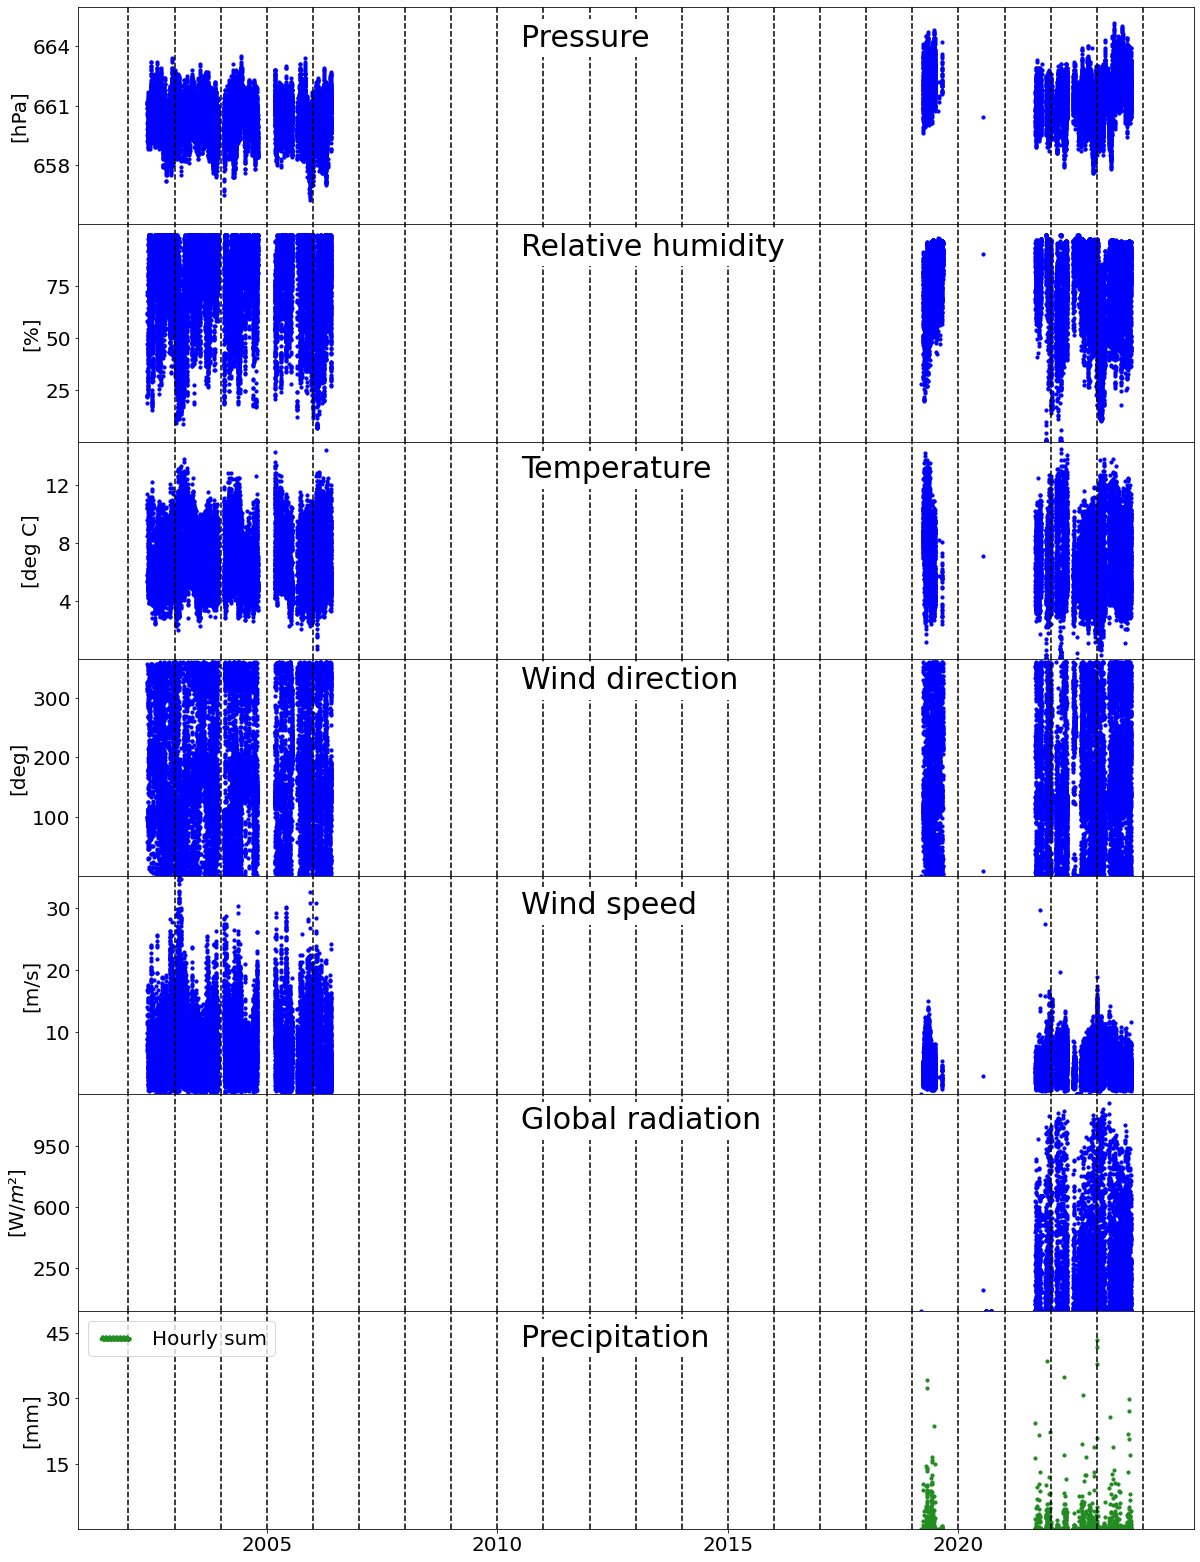

In [5]:
# Make Plot

fig = plt.figure(figsize=(20,28))
plt.subplots_adjust(hspace=0)
ax1 = plt.subplot(711)
ax2 = plt.subplot(712)
ax3 = plt.subplot(713)
ax4 = plt.subplot(714)
ax5 = plt.subplot(715)
ax6 = plt.subplot(716)
ax7 = plt.subplot(717)

# xlabel
x_dates = []
for y in range(2002,2025):
    x_dates.append(str(y)+"-01-01")

#### Pressure ####
ax1.scatter(data_meteo_all["dtm"],data_meteo_all["P"], marker="o", s= 10, c="blue", label = "Hourly average")
ax1.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["prestah0"], marker="o", s= 10, c="blue")
ax1.set_ylim(655,666)
ax1.set_ylabel("[hPa]", fontsize=20)
ax1.vlines(x = x_dates, ymin=0, ymax=750, colors="k", ls="--")
ax1.set_yticks([658,661, 664])
t = ax1.text(14800, 664, "Pressure", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax1.tick_params(axis="y", labelsize=20)

#### Relative humidity ####
ax2.scatter(data_meteo_all["dtm"],data_meteo_all["rH"], marker="o", s= 10, c="blue")
ax2.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["ure200h0"], marker="o", s= 10, c="blue")
ax2.set_ylim(0,105)
ax2.set_ylabel("[%]", fontsize=20)
ax2.vlines(x = x_dates, ymin=0, ymax=1500, colors="k", ls="--")
ax2.set_yticks([25,50, 75])
t = ax2.text(14800, 90, "Relative humidity", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax2.tick_params(axis="y", labelsize=20)

#### Temperature ####
ax3.scatter(data_meteo_all["dtm"],data_meteo_all["T"], marker="o", s= 10, c="blue")
ax3.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["tre200h0"], marker="o", s= 10, c="blue")
ax3.set_ylim(0,15)
ax3.set_ylabel("[deg C]", fontsize=20)
ax3.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax3.set_yticks([4,8, 12])
t = ax3.text(14800, 12.5, "Temperature", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax3.tick_params(axis="y", labelsize=20)

#### Wind direction ####
ax4.scatter(data_meteo_all["dtm"],data_meteo_all["wind_d"], marker="o", s= 10, c="blue")
ax4.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["dkl010h0"], marker="o", s= 10, c="blue")
ax4.set_ylim(0,365)
ax4.set_ylabel("[deg]", fontsize=20)
ax4.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax4.set_yticks([100,200, 300])
t = ax4.text(14800, 315, "Wind direction", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax4.tick_params(axis="y", labelsize=20)

#### Wind speed ####
ax5.scatter(data_meteo_all["dtm"],data_meteo_all["wind_s"], marker="o", s= 10, c="blue")
ax5.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["fkl010h0"], marker="o", s= 10, c="blue")
ax5.set_ylim(0,35)
ax5.set_ylabel("[m/s]", fontsize=20)
ax5.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax5.set_yticks([10,20, 30])
t = ax5.text(14800, 29, "Wind speed", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax5.tick_params(axis="y", labelsize=20)

#### Globalstrahlung ####
ax6.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["gre000h0"], marker="o", s= 10, c="blue")
ax6.set_ylim(0,1250)
ax6.set_ylabel("[W/$m²$]", fontsize=20)
ax6.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax6.set_yticks([250,600, 950])
t = ax6.text(14800, 1050, "Global radiation", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax6.tick_params(axis="y", labelsize=20)

#### Precipitation ####
ax7.scatter(meteo_data_MCH["timestamp"], meteo_data_MCH["rre150h0"], marker="o", s= 10, c="forestgreen", label="Hourly sum" )
ax7.set_ylim(0,50)
ax7.set_ylabel("[mm]", fontsize=20)
ax7.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax7.set_yticks([15,30, 45])
t = ax7.text(14800, 42, "Precipitation", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax7.tick_params(axis="y", labelsize=20)
ax7.tick_params(axis="x", labelsize=20)
ax7.legend(loc="upper left", fontsize=20, scatterpoints=25)
ax7.set_xticks(["2005","2010", "2015", "2020"], ["2005","2010", "2015", "2020"])

# save figure
fig.savefig(os.getcwd()+"/Plots/Meteorology.jpeg", bbox_inches='tight')